# Task 1 #Level 1 (Task: Data Exploration and Preprocessing)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
data = pd.read_csv('Dataset .csv')
data

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
num_rows = data.shape[0]
num_columns = data.shape[1]

print("Number of rows:", num_rows)
print("Number of columns:", num_columns)

Number of rows: 9551
Number of columns: 21


In [ ]:
missing_values = data.isnull().sum()
# Print the columns with missing values and their respective counts
print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Cuisines    9
dtype: int64


In [ ]:
data.dropna(inplace=True)
# Confirm that missing values have been handled
print("Missing values handled:")
print(data.isnull().sum())

Missing values handled:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


<Axes: xlabel='Aggregate rating', ylabel='Count'>

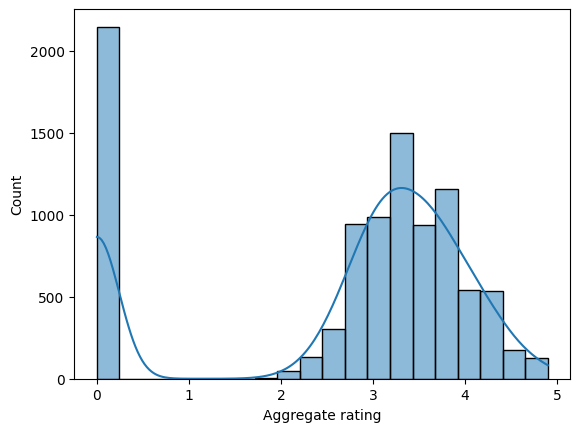

In [ ]:
sns.histplot(data['Aggregate rating'], bins=20, kde=True)

In [ ]:
# Print value counts of the target variable
print("Value counts of Aggregate rating:")
display(data['Aggregate rating'].value_counts())

Value counts of Aggregate rating:


Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     495
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     399
2.9     381
3.9     332
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     143
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      41
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64

# TASK 2 LEVEL 1 (Task: Descriptive Analysis)

In [ ]:
statistics = data.describe()
display(statistics)

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.542000e+03,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000,9542.000000
mean,9.043301e+06,18.179208,64.274997,25.848532,1200.326137,1.804968,2.665238,156.772060
std,8.791967e+06,56.451600,41.197602,11.010094,16128.743876,0.905563,1.516588,430.203324
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019312e+05,1.000000,77.081565,28.478658,250.000000,1.000000,2.500000,5.000000
50%,6.002726e+06,1.000000,77.192031,28.570444,400.000000,2.000000,3.200000,31.000000
75%,1.835260e+07,1.000000,77.282043,28.642711,700.000000,2.000000,3.700000,130.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
# Calculate mean for a specific column
mean_value = data['Average Cost for two'].mean()

# Calculate median for a specific column
median_value = data['Price range'].median()

# Calculate standard deviation for a specific column
std_deviation = data['Aggregate rating'].std()

# Print the calculated statistics
print("Mean:", mean_value)
print("Median:", median_value)
print("Standard Deviation:", std_deviation)


Mean: 1200.3261370781806
Median: 2.0
Standard Deviation: 1.5165875082081923


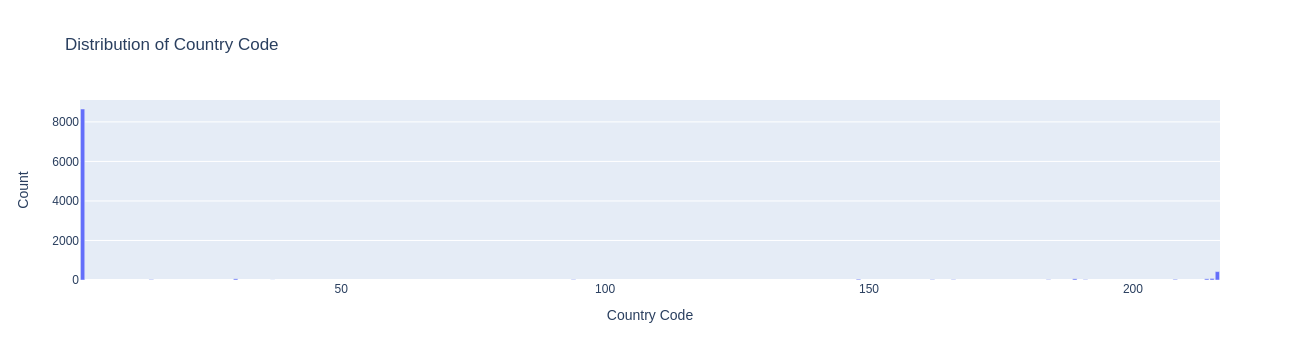

In [ ]:
# Distribution of Country Code
country_code_distribution = data['Country Code'].value_counts().reset_index()
country_code_distribution.columns = ['Country Code', 'Count']
fig_country_code = px.bar(country_code_distribution, x='Country Code', y='Count', title='Distribution of Country Code')
fig_country_code.show()

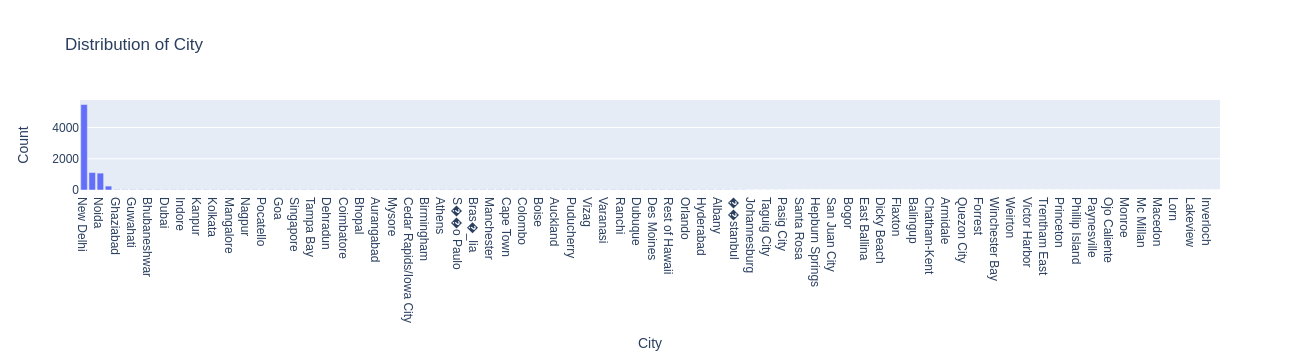

In [ ]:
# Distribution of City
city_distribution = data['City'].value_counts().reset_index()
city_distribution.columns = ['City', 'Count']
fig_city = px.bar(city_distribution, x='City', y='Count', title='Distribution of City')
fig_city.show()

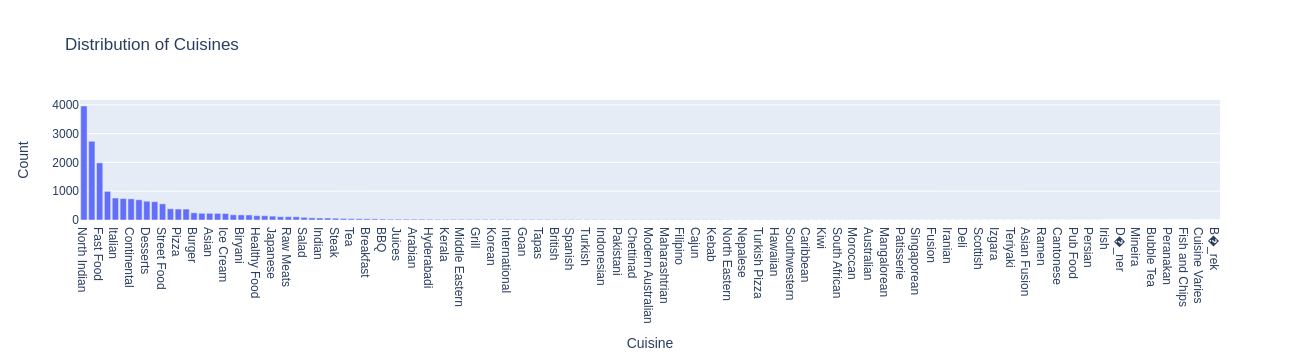

In [ ]:
# Distribution of Cuisines
cuisine_distribution = data['Cuisines'].str.split(', ', expand=True).stack().value_counts().reset_index()
cuisine_distribution.columns = ['Cuisine', 'Count']
fig_cuisine = px.bar(cuisine_distribution, x='Cuisine', y='Count', title='Distribution of Cuisines')
fig_cuisine.show()

In [ ]:
# Top cuisines with the highest number of restaurants
cuisine_counts = data['Cuisines'].str.split(', ', expand=True).stack().value_counts()
top_cuisines = cuisine_counts.head(10)  # Get the top 10 cuisines
display("Top cuisines with the highest number of restaurants:")
display(top_cuisines)

'Top cuisines with the highest number of restaurants:'

North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

In [ ]:
# Top cities with the highest number of restaurants
top_cities = data['City'].value_counts().head(10)  # Get the top 10 cities
print("\nTop cities with the highest number of restaurants:")
display(top_cities)


Top cities with the highest number of restaurants:


City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Guwahati          21
Amritsar          21
Bhubaneshwar      21
Lucknow           21
Name: count, dtype: int64

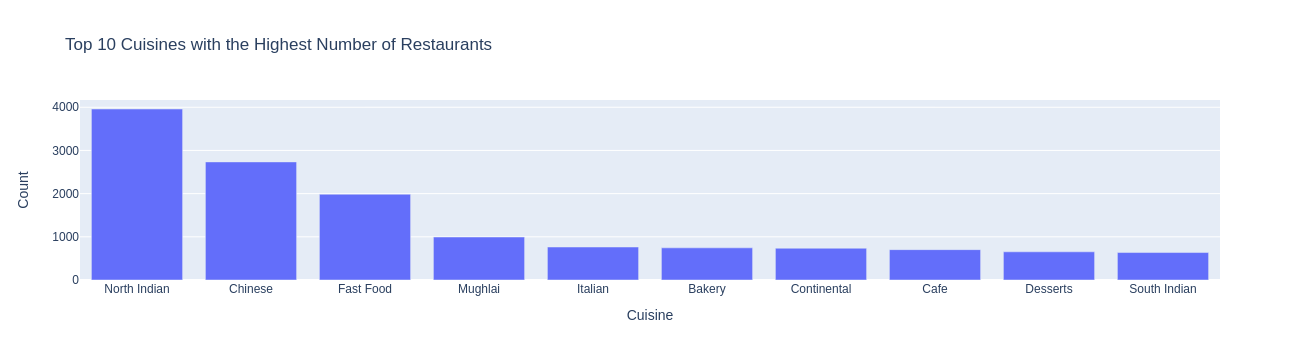

In [ ]:
# Top cuisines with the highest number of restaurants
cuisine_counts = data['Cuisines'].str.split(', ', expand=True).stack().value_counts()
top_cuisines = cuisine_counts.head(10)  # Get the top 10 cuisines
top_cuisines = top_cuisines.reset_index()
top_cuisines.columns = ['Cuisine', 'Count']
fig_cuisine = px.bar(top_cuisines, x='Cuisine', y='Count', title='Top 10 Cuisines with the Highest Number of Restaurants')
fig_cuisine.show()

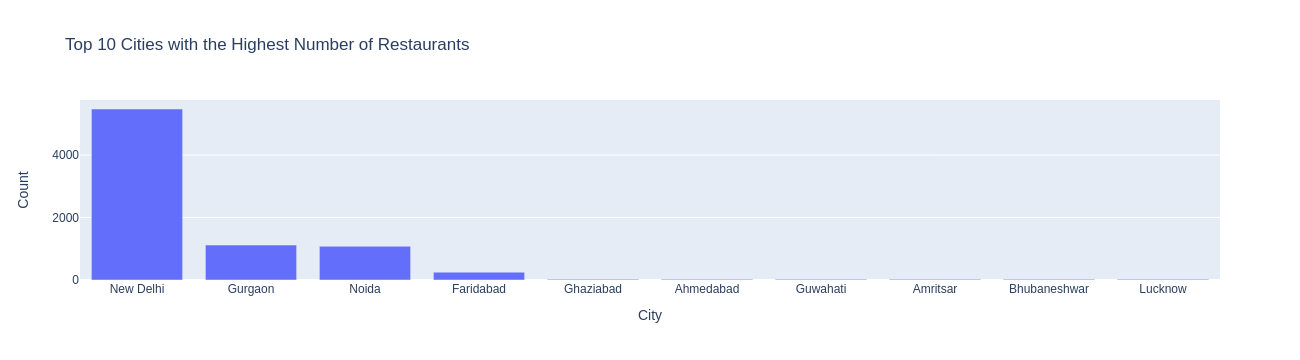

In [ ]:
# Top cities with the highest number of restaurants
top_cities = data['City'].value_counts().head(10)
top_cities = top_cities.reset_index()
top_cities.columns = ['City', 'Count']

fig_city = px.bar(top_cities, x='City', y='Count', title='Top 10 Cities with the Highest Number of Restaurants')
fig_city.show()

# TASK 3 LEVEL 1 (Task: Geospatial Analysis)

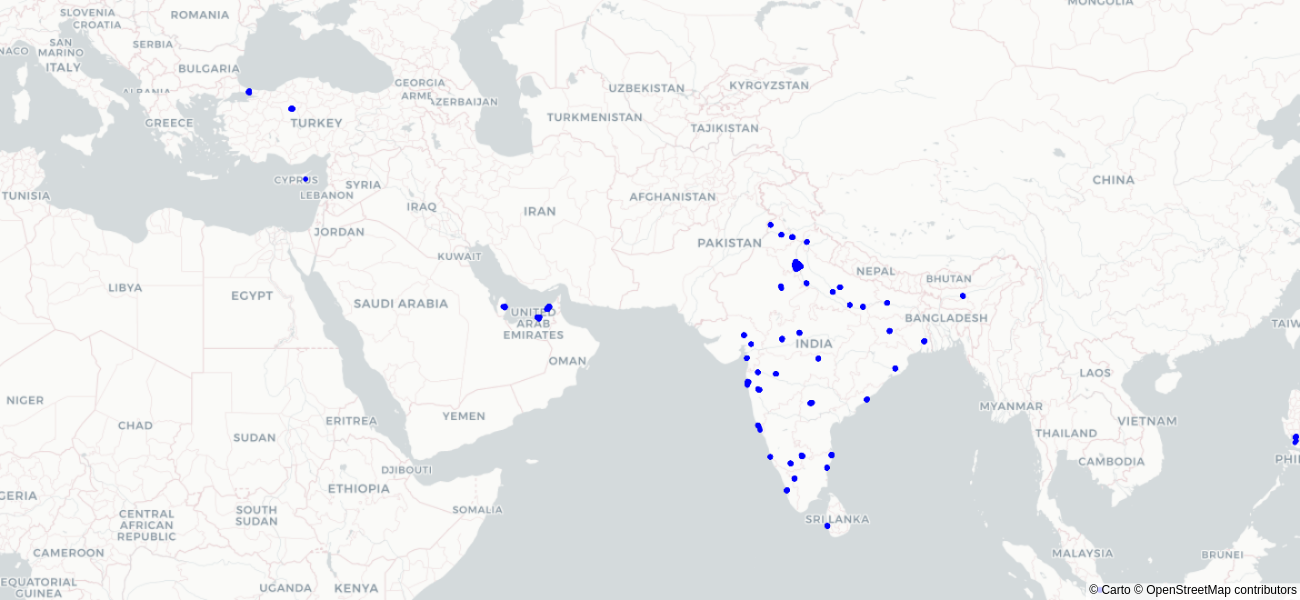

In [ ]:
# Create a Scattermapbox plot
fig = px.scatter_mapbox(data, lat='Latitude', lon='Longitude', hover_name='Restaurant Name', hover_data=['Cuisines', 'City'],
                        color_discrete_sequence=['blue'], zoom=3, height=600)

# Update layout to customize map appearance
fig.update_layout(mapbox_style="carto-positron", mapbox_zoom=3, mapbox_center = {"lat": data['Latitude'].mean(), "lon": data['Longitude'].mean()})
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Show the plot
fig.show()

/tmp/ipykernel_5418/2393003313.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




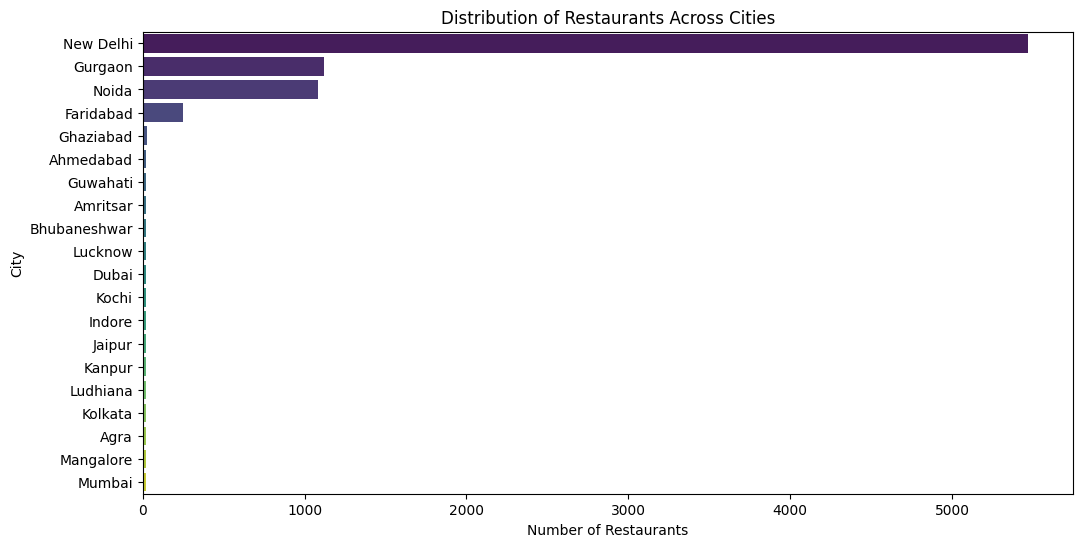

In [ ]:
plt.figure(figsize=(12, 6))
city_distribution = data['City'].value_counts().head(20)  # Top 20 cities
sns.barplot(x=city_distribution.values, y=city_distribution.index, palette='viridis')
plt.title('Distribution of Restaurants Across Cities')
plt.xlabel('Number of Restaurants')
plt.ylabel('City')
plt.show()

/tmp/ipykernel_5418/2299375732.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




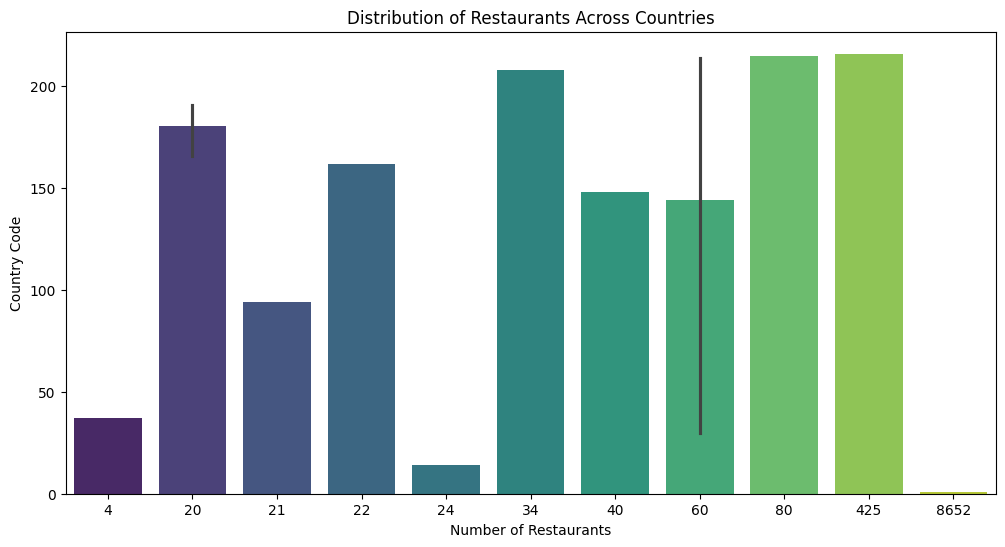

In [ ]:
# Distribution of restaurants across countries
plt.figure(figsize=(12, 6))
country_distribution = data['Country Code'].value_counts().head(20)  # Top 20 countries
sns.barplot(x=country_distribution.values, y=country_distribution.index, palette='viridis')
plt.title('Distribution of Restaurants Across Countries')
plt.xlabel('Number of Restaurants')
plt.ylabel('Country Code')
plt.show()

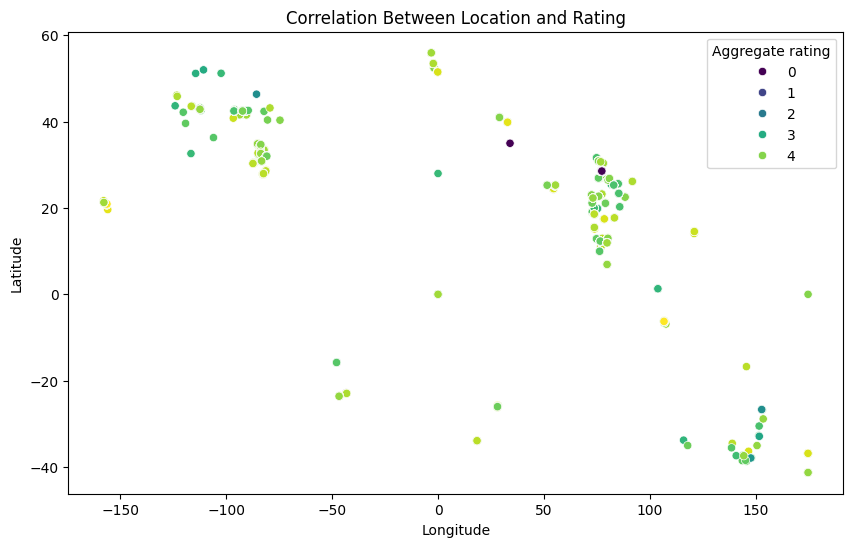

In [ ]:
# Correlation between location and rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Aggregate rating', data=data, palette='viridis')
plt.title('Correlation Between Location and Rating')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
# Correlation coefficient between location and rating
correlation_coefficient = data[['Latitude', 'Longitude', 'Aggregate rating']].corr().iloc[0, 1]
print("Correlation Coefficient between Latitude/Longitude and Rating:", correlation_coefficient)

Correlation Coefficient between Latitude/Longitude and Rating: 0.04541516449484745


# TASK 1 LEVEL 2 (Task: Table Booking and Online Delivery)

In [ ]:
# Count the number of restaurants offering table booking
num_table_booking = data['Has Table booking'].value_counts().get('Yes', 0)

# Count the number of restaurants offering online delivery
num_online_delivery = data['Has Online delivery'].value_counts().get('Yes', 0)

# Calculate the percentage of restaurants offering table booking and online delivery
total_restaurants = len(data)
percentage_table_booking = (num_table_booking / total_restaurants) * 100
percentage_online_delivery = (num_online_delivery / total_restaurants) * 100

# Print the results
print("Percentage of restaurants offering table booking:", round(percentage_table_booking, 2), "%")
print("Percentage of restaurants offering online delivery:", round(percentage_online_delivery, 2), "%")

Percentage of restaurants offering table booking: 12.14 %
Percentage of restaurants offering online delivery: 25.69 %


In [ ]:
# Group the data based on the "Has Table booking" column and calculate the average rating for each group
avg_ratings_by_table_booking = data.groupby('Has Table booking')['Aggregate rating'].mean()

# Print the average ratings for each group
print("Average Ratings:")
print(avg_ratings_by_table_booking)

Average Ratings:
Has Table booking
No     2.557956
Yes    3.441969
Name: Aggregate rating, dtype: float64


In [ ]:
# You can customize the price ranges according to your dataset
price_ranges = {
    'Cheap': (0, 10),
    'Moderate': (11, 30),
    'Expensive': (31, 60),
    'Very Expensive': (61, float('inf'))
}

# Function to categorize restaurants into price ranges
def categorize_price(price):
    for category, (min_price, max_price) in price_ranges.items():
        if min_price <= price <= max_price:
            return category
    return 'Unknown'

# Apply the categorization function to create a new column for price range
data['Price Range'] = data['Average Cost for two'].apply(categorize_price)

# Calculate the percentage of restaurants offering online delivery in each price range
online_delivery_percentage = data.groupby('Price Range')['Has Online delivery'].apply(lambda x: (x == 'Yes').mean() * 100)

# Print the results
print("Percentage of restaurants offering online delivery by price range:")
print(online_delivery_percentage)

Percentage of restaurants offering online delivery by price range:
Price Range
Cheap              0.000000
Expensive          1.333333
Moderate           0.000000
Very Expensive    27.364185
Name: Has Online delivery, dtype: float64


# TASK 2 LEVEL 2 (Task: Price Range Analysis)

In [ ]:
# Function to categorize restaurants into price ranges
def categorize_price(price):
    for category, (min_price, max_price) in price_ranges.items():
        if min_price <= price <= max_price:
            return category
    return 'Unknown'

# Apply the categorization function to create a new column for price range
data['Price Range'] = data['Average Cost for two'].apply(categorize_price)

# Determine the most common price range among all the restaurants
most_common_price_range = data['Price Range'].mode()[0]

# Print the most common price range
print("Most Common Price Range Among All Restaurants:", most_common_price_range)

Most Common Price Range Among All Restaurants: Very Expensive


In [ ]:
# Function to categorize restaurants into price ranges
def categorize_price(price):
    for category, (min_price, max_price) in price_ranges.items():
        if min_price <= price <= max_price:
            return category
    return 'Unknown'

# Apply the categorization function to create a new column for price range
data['Price Range'] = data['Average Cost for two'].apply(categorize_price)

# Calculate the average rating for each price range
avg_rating_by_price_range = data.groupby('Price Range')['Aggregate rating'].mean()

# Print the results
print("Average Rating for Each Price Range:")
print(avg_rating_by_price_range)

Average Rating for Each Price Range:
Price Range
Cheap             3.981944
Expensive         3.795556
Moderate          3.876652
Very Expensive    2.584876
Name: Aggregate rating, dtype: float64


/tmp/ipykernel_5418/2308849135.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




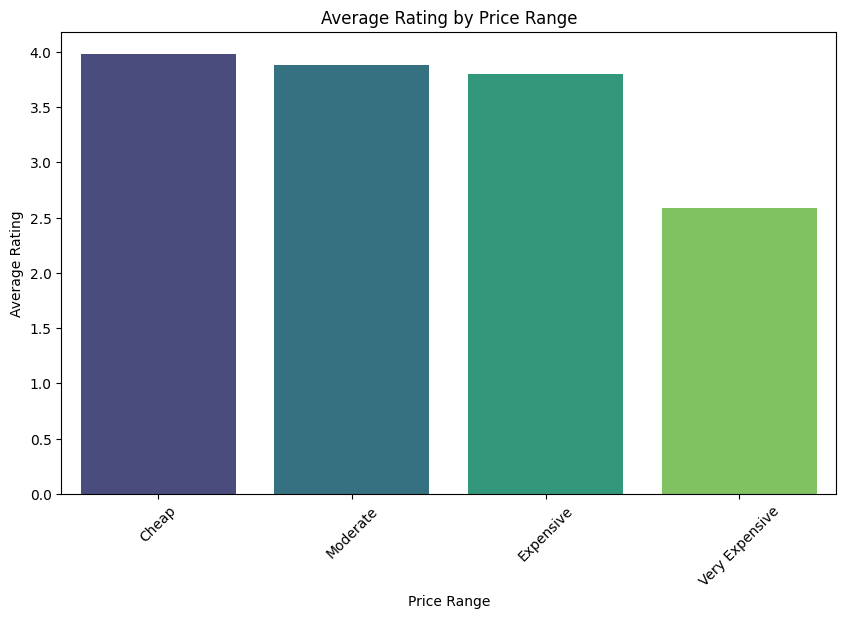

Color representing the highest average rating: (0.127568, 0.566949, 0.550556)


In [ ]:
# Apply the categorization function to create a new column for price range
data['Price Range'] = data['Average Cost for two'].apply(categorize_price)

# Calculate the average rating for each price range
avg_rating_by_price_range = data.groupby('Price Range')['Aggregate rating'].mean().reset_index()

# Sort the data by average rating in descending order
avg_rating_by_price_range.sort_values(by='Aggregate rating', ascending=False, inplace=True)

# Plot the data using a color gradient
plt.figure(figsize=(10, 6))
sns.barplot(x='Price Range', y='Aggregate rating', data=avg_rating_by_price_range, palette='viridis')
plt.title('Average Rating by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

# Identify the color representing the highest average rating
highest_rating_color = sns.color_palette('viridis', n_colors=1)[0]
print("Color representing the highest average rating:", highest_rating_color)

# TASK 3 LEVEL 2 (Task: Feature Engineering)

In [ ]:
# Extract additional features: length of restaurant name and address
data['Restaurant Name Length'] = data['Restaurant Name'].str.len()
data['Address Length'] = data['Address'].str.len()

# Display the first few rows to verify the new features
display(data[['Restaurant Name', 'Restaurant Name Length', 'Address', 'Address Length']].head())

,Restaurant Name,Restaurant Name Length,Address,Address Length
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [ ]:
# Create new features: Has Table Booking and Has Online Delivery
data['Has Table Booking'] = (data['Has Table booking'] == 'Yes').astype(int)
data['Has Online Delivery'] = (data['Has Online delivery'] == 'Yes').astype(int)

# Display the first few rows to verify the new features
display(data[['Has Table Booking', 'Has Online Delivery']].head())

,Has Table Booking,Has Online Delivery
0,1,0
1,1,0
2,1,0
3,0,0
4,1,0


# TASK 1 LEVEL 3 (Task: Feature Engineering)

In [ ]:
# Select relevant features and target variable
X = data[['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range']]  # Replace with actual feature columns
y = data['Aggregate rating']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize regression models
linear_regression = LinearRegression()
decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(random_state=42)

# Train the models
linear_regression.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

# Predict the ratings on the testing set
y_pred_lr = linear_regression.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_pred_rf = random_forest.predict(X_test)

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name} Metrics:")
    print(f"Mean Squared Error: {mse}")
    print(f"Mean Absolute Error: {mae}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression Metrics:
Mean Squared Error: 1.4866076950428955
Mean Absolute Error: 0.9972136077814122

Decision Tree Metrics:
Mean Squared Error: 2.112236773179675
Mean Absolute Error: 0.8666317443687795

Random Forest Metrics:
Mean Squared Error: 1.0937758737558934
Mean Absolute Error: 0.705188580408591



# TASK 2 LEVEL 3 (Task: Customer Preference Analysis)

/tmp/ipykernel_5418/1074460665.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_5418/1074460665.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




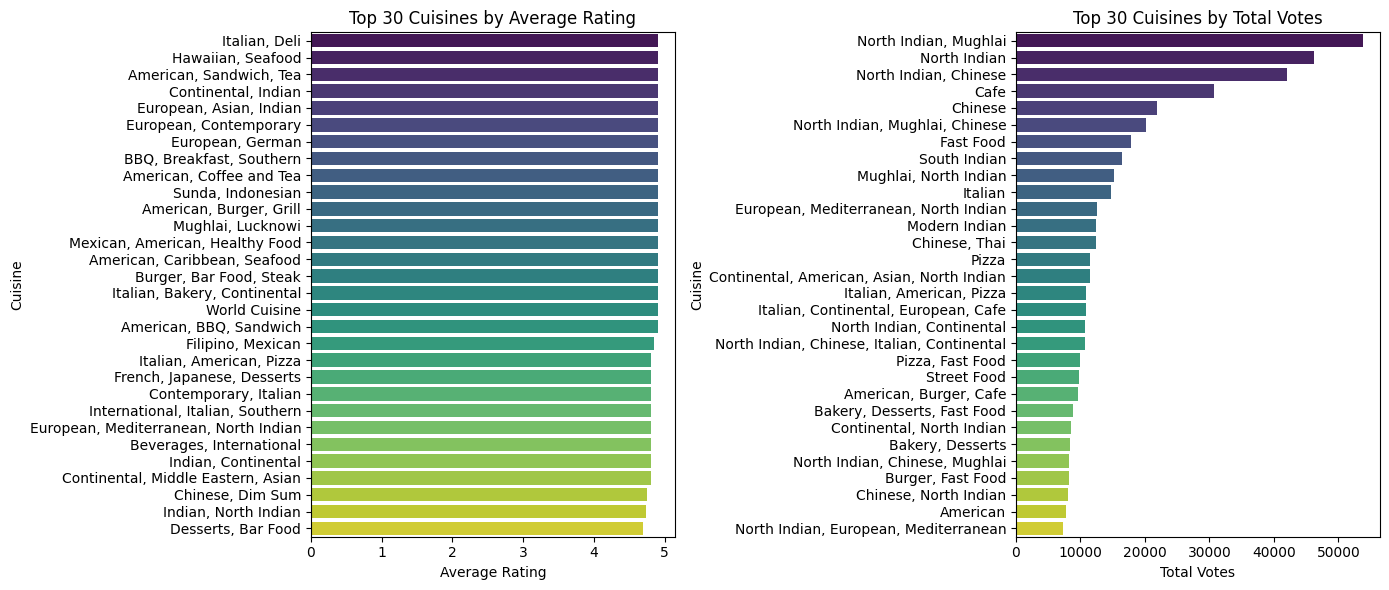

In [ ]:
# Aggregate Data
cuisine_ratings = data.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(30)
cuisine_votes = data.groupby('Cuisines')['Votes'].sum().sort_values(ascending=False).head(30)

# Visualize the Data
plt.figure(figsize=(14, 6))

# Bar chart for top 30 cuisines by average rating
plt.subplot(1, 2, 1)
sns.barplot(x=cuisine_ratings.values, y=cuisine_ratings.index, palette='viridis', orient='h')
plt.title('Top 30 Cuisines by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

# Bar chart for top 30 cuisines by total votes
plt.subplot(1, 2, 2)
sns.barplot(x=cuisine_votes.values, y=cuisine_votes.index, palette='viridis', orient='h')
plt.title('Top 30 Cuisines by Total Votes')
plt.xlabel('Total Votes')
plt.ylabel('Cuisine')

plt.tight_layout()
plt.show()

# TASK 3 LEVEL 3 (Task: Data Visualization)

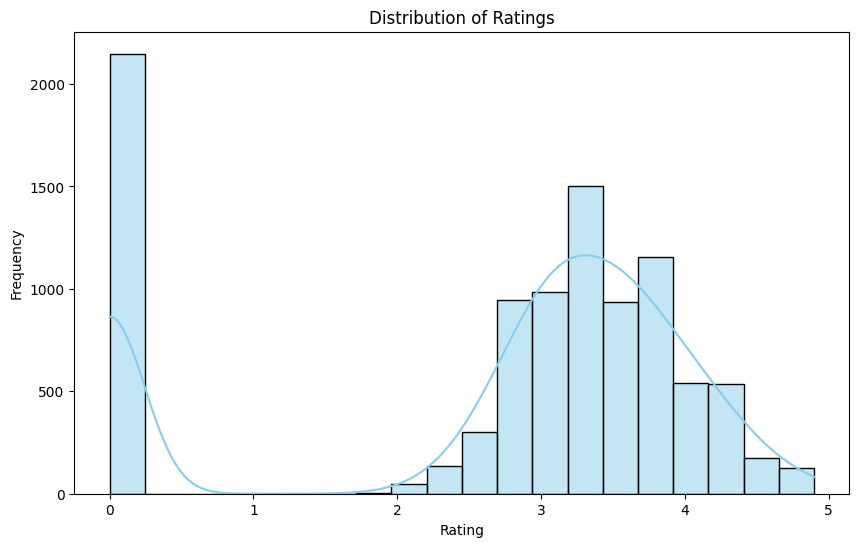

In [ ]:
# Aggregate Data: Top 30 cuisines by average rating
top_30_cuisines = data.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(30)

# Visualize the Distribution of Ratings
plt.figure(figsize=(10, 6))
sns.histplot(data['Aggregate rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_5418/718211897.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




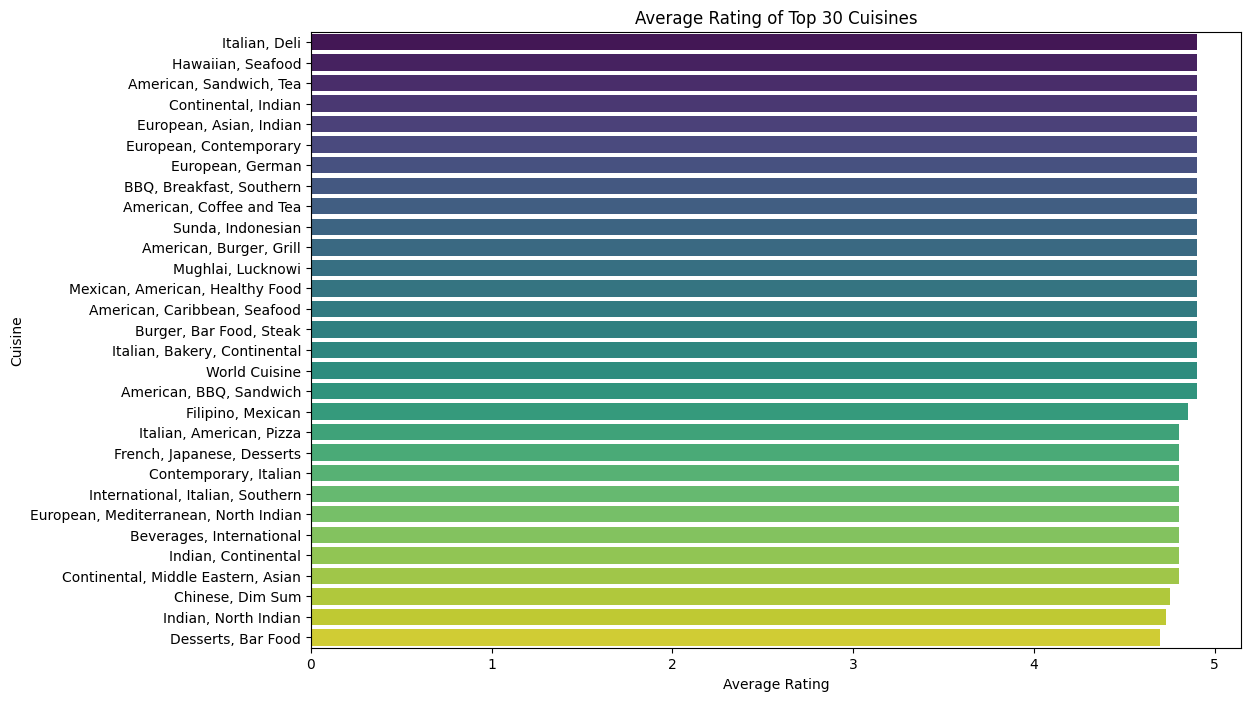

In [ ]:
# Compare Average Ratings of Top 30 Cuisines
plt.figure(figsize=(12, 8))
sns.barplot(x=top_30_cuisines.values, y=top_30_cuisines.index, palette='viridis', orient='h')
plt.title('Average Rating of Top 30 Cuisines')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.show()

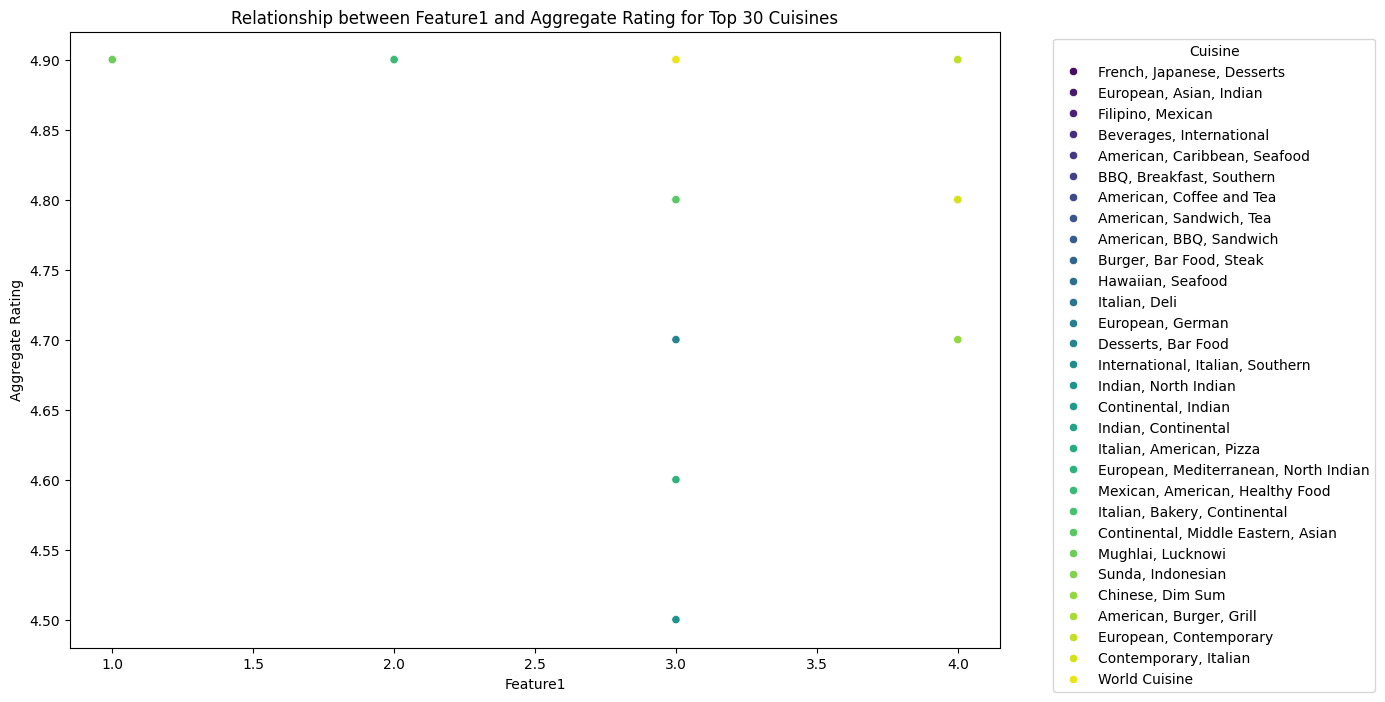

In [ ]:
# Visualize Relationship between Features and Target Variable (Aggregate Rating) for Top 30 Cuisines
top_30_cuisine_data = data[data['Cuisines'].isin(top_30_cuisines.index)]
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Price range', y='Aggregate rating', data=top_30_cuisine_data, hue='Cuisines', palette='viridis')
plt.title('Relationship between Feature1 and Aggregate Rating for Top 30 Cuisines')
plt.xlabel('Feature1')
plt.ylabel('Aggregate Rating')
plt.legend(title='Cuisine', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()